### 1. Imports and Configuration

In [ ]:
import sys
import asyncio
import logging
from pathlib import Path

# -----------------------------------------------------------------------
# Path setup -- must come before local imports.
# -----------------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from google.adk.agents                   import Agent
from google.adk.tools.agent_tool         import AgentTool
from google.genai                        import types
from IPython.display                     import display, Markdown

from config import MODEL, APP_NAME, USER_ID, make_runner, strip_emojis
from tools  import (MORTGAGE_TOOLS, RISK_TOOLS, LOAN_TOOLS,
                     INVESTMENT_TOOLS, ALL_TOOLS)

logging.basicConfig(
    level   = logging.INFO,
    format  = "%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt = "%H:%M:%S",
)
logging.getLogger("google.genai").setLevel(logging.ERROR)
log = logging.getLogger(__name__)

### 2. Runner Helper

In [ ]:
# -----------------------------------------------------------------------
# Helper to send a query, collect all events, and return the final
# response text. Separates thinking (part.thought=True) from content.
# Displays only the last final response to avoid duplicates when
# the model retries a failed tool call.
#
# ADK event model:
#   - Each LLM call, tool call, and tool response produces an Event.
#   - Events contain a Content object with a list of Part objects.
#   - Parts can be text, function_call, function_response, or thinking.
#   - Thinking parts have part.thought=True and carry the model's
#     internal reasoning.
#   - is_final_response() marks the event where the agent produces
#     its user-facing answer (as opposed to intermediate tool calls).
#
# Session and state:
#   - A session tracks one conversation. It holds events (history)
#     and state (key-value pairs shared across agents).
#   - initial_state pre-populates state keys that agents reference
#     via {key} in their instructions (needed for LoopAgent where
#     the first iteration reads keys not yet written).
#   - session_id can be passed to resume an existing session.
#   - user_id identifies the user within the session service.
# -----------------------------------------------------------------------

async def run_agent(agent, query, initial_state=None, session_id=None):
    """Send a single query to an agent and return the final response."""
    runner  = make_runner(agent)
    session = await runner.session_service.create_session(
        app_name = APP_NAME,
        user_id  = USER_ID,
        state    = initial_state or {},
    )
    sid = session_id or session.id

    # User message wrapped in ADK's Content/Part structure.
    # role="user" marks it as a user turn in the conversation.
    content = types.Content(
        role  = "user",
        parts = [types.Part(text=query)],
    )

    final_text    = None
    final_author  = None
    thinking_text = None

    # run_async yields events as the agent processes the query.
    # Multiple events are produced: one per LLM call, one per tool
    # call/response pair, and one or more final response events.
    async for event in runner.run_async(
        user_id     = USER_ID,
        session_id  = sid,
        new_message = content,
    ):
        # author identifies which agent produced this event
        # (relevant in multi-agent setups with sub-agents)
        author = getattr(event, "author", "unknown")

        # Log intermediate events: tool calls, tool responses, thinking
        if event.content and event.content.parts:
            for part in event.content.parts:
                if hasattr(part, "function_call") and part.function_call:
                    log.info("[%s] tool_call: %s(%s)",
                             author, part.function_call.name,
                             dict(part.function_call.args or {}))
                if hasattr(part, "function_response") and part.function_response:
                    log.info("[%s] tool_response: %s -> %s",
                             author, part.function_response.name,
                             str(part.function_response.response)[:200])
                if hasattr(part, "text") and part.text and getattr(part, "thought", False):
                    log.info("[%s] thinking: %s", author, part.text[:200])

        # Collect final response parts -- overwrite on each final event
        # so only the last complete response is kept (avoids duplicates
        # when the agent retries after a failed tool call)
        if event.is_final_response() and event.content and event.content.parts:
            for part in event.content.parts:
                if not hasattr(part, "text") or not part.text:
                    continue
                if getattr(part, "thought", False):
                    thinking_text = part.text
                else:
                    final_text   = strip_emojis(part.text)
                    final_author = author

    # Display once after all events are processed
    if thinking_text:
        display(Markdown(f"**Thinking ({final_author}):**\n\n{thinking_text}"))
    if final_text:
        display(Markdown(f"**{final_author}:**\n\n{final_text}"))

    return final_text

### 3. LLM-Driven Delegation -- sub_agents + transfer_to_agent

The coordinator has specialist agents as `sub_agents`. ADK provides a built-in `transfer_to_agent` tool. The coordinator's LLM decides which specialist to hand off to. Once transferred, the specialist takes over and responds directly, the coordinator does not see the specialist's response or act on it afterward. This is a full handover.

In [ ]:
# -----------------------------------------------------------------------
# A coordinator agent decides which specialist to delegate to based
# on the user query. The LLM picks the sub-agent dynamically via
# transfer_to_agent. Control is fully handed over to the specialist.
# -----------------------------------------------------------------------

mortgage_specialist = Agent(
    model       = MODEL,
    name        = "mortgage_specialist",
    description = "Handles mortgage calculations: payments, amortization, affordability.",
    instruction = (
        "You are a mortgage specialist. Answer the user's mortgage-related "
        "question using the available tools. Be precise with numbers."
    ),
    tools = MORTGAGE_TOOLS,
)

risk_specialist = Agent(
    model       = MODEL,
    name        = "risk_specialist",
    description = "Handles credit risk scoring and loan risk assessment.",
    instruction = (
        "You are a risk analyst. Evaluate the applicant's risk profile "
        "using the available tools. Report the score, category, and any flags."
    ),
    tools = RISK_TOOLS,
)

investment_specialist = Agent(
    model       = MODEL,
    name        = "investment_specialist",
    description = "Handles investment projections, ROI, and savings goals.",
    instruction = (
        "You are an investment analyst. Use the available tools to project "
        "returns, calculate ROI, or plan savings goals."
    ),
    tools = INVESTMENT_TOOLS,
)

coordinator = Agent(
    model       = MODEL,
    name        = "coordinator",
    description = "Routes financial queries to the right specialist.",
    instruction = (
        "You are a financial services coordinator. Based on the user's question, "
        "delegate to the appropriate specialist:\n"
        "- mortgage_specialist for payment calculations, amortization, affordability\n"
        "- risk_specialist for credit risk or loan risk evaluation\n"
        "- investment_specialist for compound interest, ROI, savings goals\n"
        "Transfer to the best-fit specialist. Do not answer directly."
    ),
    sub_agents = [mortgage_specialist, risk_specialist, investment_specialist],
)

In [4]:
# -----------------------------------------------------------------------
# Mortgage query -- should route to mortgage_specialist.
# -----------------------------------------------------------------------

response = await run_agent(
    coordinator,
    "How much can I afford if I make 140k and have 800/mo in debts? Rate is 5.75%.",
)

04:08:42  INFO      Sending out request, model: gemini-3-flash-preview, backend: GoogleLLMVariant.GEMINI_API, stream: False
04:08:43  INFO      Response received from the model.
04:08:43  WARNING   Warning: there are non-text parts in the response: ['function_call'], returning concatenated text result from text parts. Check the full candidates.content.parts accessor to get the full model response.
04:08:43  INFO      [coordinator] tool_call: transfer_to_agent({'agent_name': 'mortgage_specialist'})
04:08:43  INFO      [coordinator] tool_response: transfer_to_agent -> {'result': None}
04:08:43  INFO      Sending out request, model: gemini-3-flash-preview, backend: GoogleLLMVariant.GEMINI_API, stream: False
04:08:45  INFO      Response received from the model.
04:08:45  INFO      [mortgage_specialist] tool_call: calculate_affordability({'annual_rate': 5.75, 'monthly_debts': 800, 'annual_income': 140000})
04:08:45  INFO      [mortgage_specialist] tool_response: calculate_affordability -> {

**mortgage_specialist:**

Based on an annual income of $140,000 and monthly debts of $800, here is an estimate of what you can afford with a 5.75% interest rate on a 30-year term:

*   **Maximum Home Price:** $722,560
*   **Maximum Monthly Mortgage Payment (P&I):** $4,216.67
*   **Total Monthly Debt (including mortgage):** $5,016.67
*   **Debt-to-Income (DTI) Ratio:** 43%

This calculation assumes a standard 43% debt-to-income ratio and does not include a down payment. If you have a down payment saved, you can add that amount to the maximum home price of $722,560.

In [5]:
# -----------------------------------------------------------------------
# Risk query -- should route to risk_specialist.
# -----------------------------------------------------------------------

response = await run_agent(
    coordinator,
    "Score my credit risk: 680 credit score, 42% DTI, 0.92 LTV, "
    "2 years employed, 1 missed payment.",
)

04:09:24  INFO      Sending out request, model: gemini-3-flash-preview, backend: GoogleLLMVariant.GEMINI_API, stream: False
04:09:25  INFO      Response received from the model.
04:09:25  INFO      [coordinator] tool_call: transfer_to_agent({'agent_name': 'risk_specialist'})
04:09:25  INFO      [coordinator] tool_response: transfer_to_agent -> {'result': None}
04:09:25  INFO      Sending out request, model: gemini-3-flash-preview, backend: GoogleLLMVariant.GEMINI_API, stream: False
04:09:27  INFO      Response received from the model.
04:09:27  INFO      [risk_specialist] tool_call: calculate_credit_risk_score({'ltv_ratio': 0.92, 'credit_score': 680, 'missed_payments_last_2y': 1, 'dti_ratio': 42, 'employment_years': 2})
04:09:27  INFO      [risk_specialist] tool_response: calculate_credit_risk_score -> {'composite_score': 48, 'max_possible_score': 100, 'risk_category': 'ELEVATED_RISK', 'component_scores': {'credit_history': {'score': 20, 'max': 35}, 'debt_to_income': {'score': 8, 'max'

**risk_specialist:**

Based on the information provided, here is your credit risk profile assessment:

*   **Composite Credit Risk Score:** 48 / 100
*   **Risk Category:** **ELEVATED RISK**

### Component Breakdown
*   **Credit History:** 20/35 (Score of 680)
*   **Debt-to-Income (DTI):** 8/25 (42% is on the higher side)
*   **Loan-to-Value (LTV):** 5/20 (0.92 indicates low equity)
*   **Employment Stability:** 7/10 (2 years at current employer)
*   **Derogatory Marks:** 8/10 (Affected by missed payments)

### Key Concerns & Flags
*   **Missed Payments:** You have 1 recorded missed payment within the last 2 years, which negatively impacts your score.
*   **High LTV:** A 0.92 LTV ratio indicates you have less than 10% equity, which increases the risk to the lender.
*   **DTI Ratio:** A 42% DTI is approaching the typical maximum limit for many conventional loan products.

### 4. AgentTool -- Agent as a Callable Tool

With `AgentTool`, the parent agent wraps another agent as a tool it can call. Unlike `sub_agents` + `transfer_to_agent`, the parent stays in control: it calls the agent-tool, receives the result back, and can then reason over it, call more tools, or synthesise a final answer.

In [7]:
# -----------------------------------------------------------------------
# Three specialist agents wrapped as AgentTools.
# The orchestrator calls them like functions and receives results back,
# then synthesises a final answer.
# -----------------------------------------------------------------------

mortgage_tool_agent = Agent(
    model       = MODEL,
    name        = "mortgage_tool",
    description = "Calculates mortgage payments, amortization, and affordability.",
    instruction = (
        "Answer the mortgage question using the available tools. "
        "Return only the key figures."
    ),
    tools = MORTGAGE_TOOLS,
)

risk_tool_agent = Agent(
    model       = MODEL,
    name        = "risk_tool",
    description = "Evaluates credit risk and loan risk.",
    instruction = (
        "Evaluate the risk profile using the available tools. "
        "Return the risk level, score, and any flags."
    ),
    tools = RISK_TOOLS,
)

# Wrap agents as tools using AgentTool
mortgage_agent_tool = AgentTool(agent=mortgage_tool_agent)
risk_agent_tool     = AgentTool(agent=risk_tool_agent)

orchestrator = Agent(
    model       = MODEL,
    name        = "orchestrator",
    description = "Analyses a property purchase by calling specialist agents as tools.",
    instruction = (
        "You are a financial orchestrator. For the property described by the user:\n"
        "1. Use the mortgage_tool to calculate the monthly payment.\n"
        "2. Use the risk_tool to assess the loan risk.\n"
        "3. Synthesise both results into a final recommendation.\n"
        "Call the agent tools, read their results, and produce the final answer."
    ),
    tools = [mortgage_agent_tool, risk_agent_tool],
)


In [8]:
# -----------------------------------------------------------------------
# The orchestrator should call both agent-tools, get results back,
# and produce a combined recommendation.
# -----------------------------------------------------------------------

response = await run_agent(
    orchestrator,
    "500k house, 100k down, 6.0% rate, 30yr. "
    "Buyer: 120k income, 600/mo debts, 710 credit score.",
)

04:15:36  INFO      Sending out request, model: gemini-3-flash-preview, backend: GoogleLLMVariant.GEMINI_API, stream: False
04:15:38  INFO      Response received from the model.
04:15:38  INFO      [orchestrator] tool_call: mortgage_tool({'request': 'Calculate monthly payment for a $400,000 loan ($500,000 price - $100,000 down) at 6.0% interest for 30 years.'})
04:15:38  INFO      [orchestrator] tool_call: risk_tool({'request': 'Assess loan risk for a buyer with $120,000 annual income, $600 monthly debt, and a 710 credit score. Loan amount is $400,000 for a $500,000 property.'})
04:15:38  INFO      Sending out request, model: gemini-3-flash-preview, backend: GoogleLLMVariant.GEMINI_API, stream: False
04:15:38  INFO      Sending out request, model: gemini-3-flash-preview, backend: GoogleLLMVariant.GEMINI_API, stream: False
04:15:39  INFO      Response received from the model.
04:15:39  INFO      Sending out request, model: gemini-3-flash-preview, backend: GoogleLLMVariant.GEMINI_API, st

**orchestrator:**

Based on the financial details provided, here is the analysis and recommendation for the property purchase:

### **1. Financial Summary**
*   **Monthly Mortgage Payment:** **$2,398.20** (Principal & Interest)
*   **Total Interest over 30 Years:** $463,352.76
*   **Total Cost of Loan:** $863,352.76

### **2. Risk & Affordability Assessment**
The loan assessment indicates a **Low Risk** profile with a composite score of **80/100**.

*   **Debt-to-Income (DTI) Ratio:** Your total monthly debt (existing $600 + new $2,398.20) results in a **DTI of approximately 30%**. This is well below the standard 36–43% threshold used by lenders, indicating the payment is comfortably affordable relative to your $120,000 annual income.
*   **Loan-to-Value (LTV):** With a 20% down payment ($100k), your LTV is **80%**. This is an ideal position as it typically eliminates the need for Private Mortgage Insurance (PMI) and provides immediate equity in the home.
*   **Credit Strength:** A credit score of **710** is considered "Good" to "Very Good," allowing for competitive interest rates and a high likelihood of approval.

### **3. Recommendation**
**Strong Approve.** 

This purchase is financially sound. You are entering the loan with a healthy equity cushion, and the monthly obligations are well-proportioned to your income. 

**Next Steps:**
*   **Budget for "Hidden" Costs:** Remember that the $2,398.20 payment covers only principal and interest. You should budget an additional **$400–$600 per month** for property taxes and homeowners insurance (escrow).
*   **Maintenance Fund:** Set aside 1% of the home's value ($5,000/year) for ongoing maintenance and repairs.

### 5. Comparison: sub_agents vs AgentTool

| Aspect | sub_agents + transfer_to_agent | AgentTool |
|--------|-------------------------------|-----------|
| Control flow | Full handover - specialist responds directly | Invoke and return - parent stays in control |
| Parent sees result | No | Yes - result comes back as tool response |
| Multi-step reasoning | Specialist handles everything | Parent can chain multiple agent-tool calls |
| Use case | Routing/dispatch to independent specialists | Hierarchical decomposition, parent synthesises |
| Built-in tool | `transfer_to_agent` (auto-provided) | Wraps agent via `AgentTool(agent=...)` |

### 6. Small-to-Big Model Delegation

A lightweight model handles planning and simple tasks. When it encounters something that needs deeper reasoning, it delegates to a more capable
model via AgentTool, receives the result, and continues. This keeps cost and latency low for routine work while accessing frontier-quality reasoning only when needed.

In [9]:
# -----------------------------------------------------------------------
# Small model (3.1 Flash Lite) handles triage and simple calculations.
# Big model (3 Flash) handles complex multi-factor analysis.
# The small agent stays in control and only escalates when needed.
# -----------------------------------------------------------------------

SMALL_MODEL = "gemini-3.1-flash-lite-preview"
BIG_MODEL   = "gemini-3-flash-preview"

# The "big brain" agent handles complex analysis requiring deeper reasoning.
# It is not called directly but only through the small agent's tool list.
complex_analyst = Agent(
    model       = BIG_MODEL,
    name        = "complex_analyst",
    description = (
        "Performs complex multi-factor financial analysis that requires "
        "weighing tradeoffs, comparing multiple scenarios, or producing "
        "detailed risk assessments. Call this when the task involves "
        "more than a single straightforward calculation."
    ),
    instruction = (
        "You are a senior financial analyst. Use the available tools to "
        "perform a thorough analysis of the request. Provide concrete "
        "numbers and a clear recommendation."
    ),
    tools = ALL_TOOLS,
)

complex_analyst_tool = AgentTool(agent=complex_analyst)

# The "small brain" agent handles triage, simple lookups, and routing.
# It can do basic calculations itself but escalates complex work.
triage_agent = Agent(
    model       = SMALL_MODEL,
    name        = "triage_agent",
    description = "Fast, lightweight financial assistant.",
    instruction = (
        "You are a fast financial assistant. Handle simple, single-tool "
        "questions yourself using your tools (e.g. a basic mortgage payment, "
        "a single compound interest projection, or a DTI ratio check).\n\n"
        "If the user's request involves multiple factors, comparisons across "
        "scenarios, or requires weighing tradeoffs (e.g. buy vs rent, "
        "full risk assessment with recommendations, multi-loan comparison "
        "with eligibility), delegate to the complex_analyst tool and "
        "return its result to the user.\n\n"
        "Do not attempt complex multi-step analysis yourself."
    ),
    tools = MORTGAGE_TOOLS + LOAN_TOOLS + INVESTMENT_TOOLS + [complex_analyst_tool],
)

In [10]:
# -----------------------------------------------------------------------
# Simple query -- triage_agent should handle this itself using
# the small model. No need to escalate.
# -----------------------------------------------------------------------

response = await run_agent(
    triage_agent,
    "What is the monthly payment on a 300k loan at 6% for 30 years?",
)

04:35:29  INFO      Sending out request, model: gemini-3.1-flash-lite-preview, backend: GoogleLLMVariant.GEMINI_API, stream: False
04:35:30  INFO      Response received from the model.
04:35:30  INFO      [triage_agent] tool_call: calculate_monthly_payment({'principal': 300000, 'term_years': 30, 'annual_rate': 6})
04:35:30  INFO      [triage_agent] tool_response: calculate_monthly_payment -> {'principal': 300000, 'down_payment': 0.0, 'loan_amount': 300000.0, 'annual_rate': 6, 'term_years': 30, 'monthly_payment': 1798.65, 'total_paid': 647514.57, 'total_interest': 347514.57, 'loan_to_value
04:35:30  INFO      Sending out request, model: gemini-3.1-flash-lite-preview, backend: GoogleLLMVariant.GEMINI_API, stream: False
04:35:31  INFO      Response received from the model.


**triage_agent:**

The monthly payment on a $300,000 loan at a 6% annual interest rate for 30 years is $1,798.65.

In [11]:
# -----------------------------------------------------------------------
# Complex query -- triage_agent should recognise this needs deeper
# analysis and escalate to complex_analyst (big model).
# -----------------------------------------------------------------------

response = await run_agent(
    triage_agent,
    "I earn 95k with 800/mo debts and a 710 credit score. "
    "Compare buying a 400k house with 60k down vs investing that 60k "
    "for 10 years at 8%. Which is the better financial decision and why?",
)

04:35:57  INFO      Sending out request, model: gemini-3.1-flash-lite-preview, backend: GoogleLLMVariant.GEMINI_API, stream: False
04:35:58  INFO      Response received from the model.
04:35:58  INFO      [triage_agent] tool_call: complex_analyst({'request': 'Compare buying a $400,000 house with a $60,000 down payment (at current market rates for a $340,000 loan) versus investing that $60,000 for 10 years at an 8% annual return. The user earns $95,000/year and has $800/month in existing debts, with a 710 credit score. Evaluate which is the better financial decision, considering factors like mortgage interest, potential property appreciation, and investment compound growth. Provide a balanced analysis of the trade-offs.'})
04:35:58  INFO      Sending out request, model: gemini-3-flash-preview, backend: GoogleLLMVariant.GEMINI_API, stream: False
04:36:04  INFO      Response received from the model.
04:36:04  INFO      Sending out request, model: gemini-3-flash-preview, backend: GoogleLLM

**triage_agent:**

The analysis above compares the two financial paths over a 10-year horizon. In summary, **buying the home builds significantly more wealth** due to the power of leverage—you are earning appreciation on the full $400k asset value rather than just your $60k investment.

However, the "better" decision depends on your life goals:

*   **Choose to buy** if you plan to stay in the area for at least 7–10 years. The equity growth typically outweighs market returns, and you gain the benefit of locking in your housing costs against inflation.
*   **Choose to invest** if you anticipate moving for work or personal reasons within the next 5 years. Selling a home involves transaction costs (often 6% in commissions) that can erase the equity gains you made in a short time.

**Next Steps:**
1.  **Check Local Rents:** Compare the $2,149 mortgage payment (P&I) against the cost of renting a similar property. If rent is significantly lower, investing the difference could narrow the gap between the two outcomes.
2.  **Account for Hidden Costs:** Remember that owning a home includes property taxes, insurance, and maintenance costs (roughly 1% of home value annually), which aren't required when renting and investing.

If you would like to run a specific "what-if" scenario—such as adjusting for property taxes or comparing the rent-vs-buy breakeven point—let me know!

### 7. Ping-Pong Delegation
Notes:
For true ping-pong between two agents (A calls B, B reasons and calls A back), ADK 1.x doesn't support that natively. There would be circular reference issues. For that pattern it has to be built manually with a custom loop: agent A produces output, feed it to agent B, B produces output, feed it back to A, repeat until done. This pattern is already achieved through the LoopAgent.


### 8. Multi-Level Agent Graph

In [17]:
from google.adk.agents.sequential_agent import SequentialAgent
from google.adk.agents.parallel_agent   import ParallelAgent

LITE_MODEL = "gemini-3.1-flash-lite-preview"
MODEL  = "gemini-3-flash-preview"

In [ ]:
# -----------------------------------------------------------------------
# Level 3 -- Lending specialists (leaf agents with tools)
# -----------------------------------------------------------------------

mortgage_calc = Agent(
    model       = LITE_MODEL,
    name        = "mortgage_calc",
    description = "Calculates mortgage payments.",
    instruction = (
        "Calculate the monthly mortgage payment for the property described "
        "in the user query. Use the calculate_monthly_payment tool. "
        "Output only the key figures."
    ),
    tools      = MORTGAGE_TOOLS,
    output_key = "mortgage_data",
)

eligibility_check = Agent(
    model       = LITE_MODEL,
    name        = "eligibility_check",
    description = "Checks loan program eligibility.",
    instruction = (
        "Check loan eligibility for the applicant described in the user query. "
        "Use the check_loan_eligibility tool. Output the result."
    ),
    tools      = LOAN_TOOLS,
    output_key = "eligibility_data",
)

risk_review = Agent(
    model       = MODEL,
    name        = "risk_review",
    description = "Assesses loan risk.",
    instruction = (
        "Using the mortgage details in {mortgage_data}, assess the loan risk "
        "for the applicant described in the user query. "
        "Use the assess_loan_risk tool. Output the result."
    ),
    tools      = RISK_TOOLS,
    output_key = "risk_data",
)

lending_summary = Agent(
    model       = LITE_MODEL,
    name        = "lending_summary",
    description = "Summarises the full lending assessment.",
    instruction = (
        "Produce a concise lending assessment from these results:\n"
        "Mortgage: {mortgage_data}\n"
        "Eligibility: {eligibility_data}\n"
        "Risk: {risk_data}\n"
        "State the monthly payment, eligible programs, risk level, "
        "and whether to approve."
    ),
)

# -----------------------------------------------------------------------
# Level 2 -- Lending (Sequential wrapping Parallel + Risk + Summary)
# -----------------------------------------------------------------------

parallel_assessment = ParallelAgent(
    name        = "parallel_assessment",
    description = "Runs mortgage calculation and eligibility check concurrently.",
    sub_agents  = [mortgage_calc, eligibility_check],
)

lending_pipeline = SequentialAgent(
    name        = "lending_pipeline",
    description = "Full lending assessment: parallel calc+eligibility, then risk, then summary.",
    sub_agents  = [parallel_assessment, risk_review, lending_summary],
)

# -----------------------------------------------------------------------
# Level 2 -- Investment advisor (standalone agent with tools)
# -----------------------------------------------------------------------

investment_advisor = Agent(
    model       = LITE_MODEL,
    name        = "investment_advisor",
    description = (
        "Projects investment growth for a given principal, contribution, "
        "rate, and time horizon."
    ),
    instruction = (
        "You are an investment advisor. Use the available tools to project "
        "returns for the scenario described. Output the key figures: "
        "future value, total contributions, and total interest earned."
    ),
    tools = INVESTMENT_TOOLS,
)

# -----------------------------------------------------------------------
# Level 1 -- Orchestrator (calls departments as tools, synthesises)
# -----------------------------------------------------------------------

lending_tool    = AgentTool(agent=lending_pipeline)
investment_tool = AgentTool(agent=investment_advisor)

orchestrator = Agent(
    model       = MODEL,
    name        = "orchestrator_v2",
    description = "Coordinates full financial analysis across departments.",
    instruction = (
        "You are a senior financial coordinator. For the user's query:\n"
        "1. Use lending_pipeline to get a full lending assessment "
        "(mortgage payment, eligibility, risk).\n"
        "2. Use investment_advisor to project what the down payment "
        "would grow to if invested instead.\n"
        "3. Synthesise both results into a final buy-vs-invest "
        "recommendation with concrete numbers.\n"
        "Call both tools, wait for results, then produce your analysis."
    ),
    tools = [lending_tool, investment_tool],
)

In [19]:
# -----------------------------------------------------------------------
# Test query that exercises the full graph: orchestrator calls both
# departments, lending runs parallel + sequential internally,
# investment projects growth, orchestrator synthesises.
# -----------------------------------------------------------------------

response = await run_agent(
    orchestrator,
    "I earn 120k/year, have 500/mo in debts, credit score 720. "
    "I'm looking at a 450k house with 80k down at 6.5% for 30 years. "
    "If I invested that 80k instead at 7% for 15 years with 500/mo contributions, "
    "what would I have? Which path is better financially?",
)

04:59:03  INFO      Sending out request, model: gemini-3-flash-preview, backend: GoogleLLMVariant.GEMINI_API, stream: False
04:59:05  INFO      Response received from the model.
04:59:05  INFO      [orchestrator_v2] tool_call: lending_pipeline({'request': 'Income: 120000, Monthly Debt: 500, Credit Score: 720, House Price: 450000, Down Payment: 80000, Interest Rate: 0.065, Term: 30 years'})
04:59:05  INFO      [orchestrator_v2] tool_call: investment_advisor({'request': 'Principal: 80000, Annual Interest Rate: 0.07, Years: 15, Monthly Contribution: 500'})
04:59:05  INFO      Sending out request, model: gemini-3.1-flash-lite-preview, backend: GoogleLLMVariant.GEMINI_API, stream: False
04:59:05  INFO      Sending out request, model: gemini-3.1-flash-lite-preview, backend: GoogleLLMVariant.GEMINI_API, stream: False
04:59:05  INFO      Sending out request, model: gemini-3.1-flash-lite-preview, backend: GoogleLLMVariant.GEMINI_API, stream: False
04:59:06  INFO      Response received from the 

**orchestrator_v2:**

To help you decide between buying the home or investing the capital, I have coordinated a dual analysis of your mortgage eligibility and your projected investment growth.

### **1. Real Estate Analysis (Buying)**
Based on your $120k income and $500 monthly debt, you are in a strong position to buy.
*   **Loan Amount:** $370,000 (after $80,000 down)
*   **Monthly Payment (P&I):** $2,338.65
*   **Total Monthly Housing Cost:** Estimated at **$2,850 – $2,950** (including taxes, insurance, and PMI).
*   **Debt-to-Income (DTI):** ~28.4% (Well within the "healthy" range for lenders).
*   **15-Year Outlook:** If the home appreciates at a modest 3% annually, it could be worth approximately **$701,000** in 15 years. With a remaining loan balance of roughly $267,000, you would have **$434,000 in home equity.**

### **2. Investment Analysis (Investing)**
If you chose to rent instead and invested your down payment and the extra cash:
*   **Initial Investment:** $80,000
*   **Monthly Contribution:** $500
*   **Annual Return:** 7%
*   **15-Year Future Value:** **$386,396.89**
*   **Total Gains:** You would have earned $216,396 in interest on top of your $170,000 total contributions.

### **Financial Comparison**

| Metric | Buying (Home Equity) | Investing (Brokerage) |
| :--- | :--- | :--- |
| **Projected Value (15 Yrs)** | ~$434,000 | ~$386,397 |
| **Liquidity** | Low (Tied to the house) | High (Cash available) |
| **Monthly Commitment** | ~$2,900 (Fixed) | Rent + $500 (Variable) |
| **Tax Advantage** | Mortgage interest/tax deductions | Capital gains taxes apply |

### **The Verdict**
**The Buying Path** is likely to result in a higher net worth ($434k vs $386k) over 15 years, primarily due to the power of **leverage**. You are gaining appreciation on a $450,000 asset while only putting $80,000 down. Additionally, the mortgage locks in your housing cost, whereas rent will likely increase significantly over 15 years.

**The Investment Path** is superior if you prioritize **liquidity** or if your local rental market is significantly cheaper than a $2,900 mortgage. If you can rent a comparable home for much less than $2,400 (allowing you to invest *more* than $500/month), the investment path could outperform the house.

**Recommendation:** Given your low DTI and strong credit, **buying is the stronger financial move** for long-term wealth building, provided you plan to stay in the home for at least 7–10 years to offset closing costs and front-loaded interest.

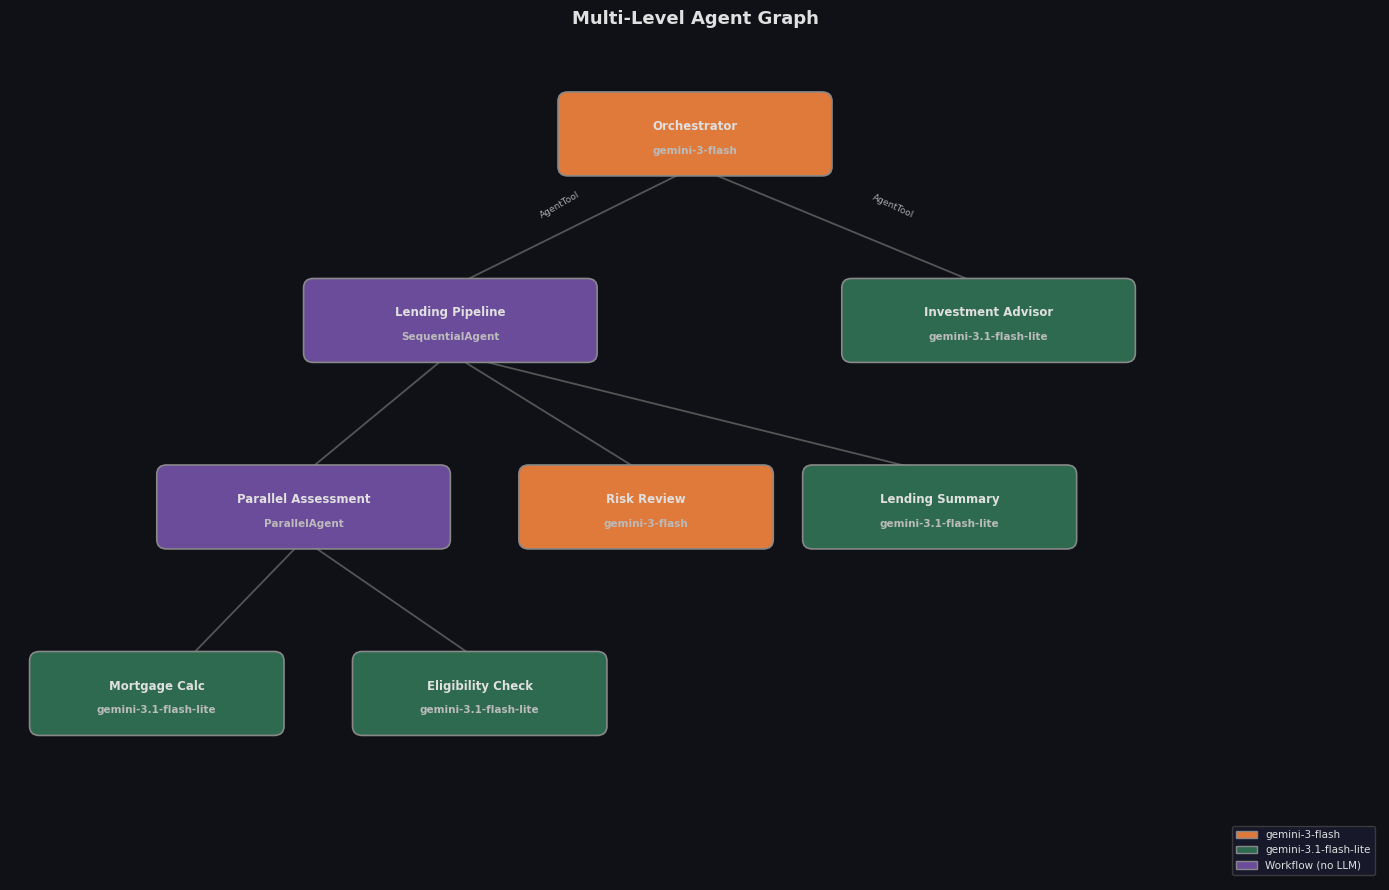

In [24]:
# -----------------------------------------------------------------------
# Agent graph visualisation
# -----------------------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 14)
ax.set_ylim(0, 9)
ax.axis("off")
fig.patch.set_facecolor("#0f1117")

# -----------------------------------------------------------------------
# Colour scheme by model tier
# -----------------------------------------------------------------------

C_STD  = "#e07a3a"   # gemini-3-flash
C_LITE = "#2d6a4f"   # gemini-3.1-flash-lite
C_WKFL = "#6b4c9a"   # workflow agents (no model)
C_TEXT = "#e0e0e0"
C_EDGE = "#555555"

def draw_node(x, y, label, sublabel, color, w=2.4, h=0.7):
    rect = mpatches.FancyBboxPatch(
        (x - w / 2, y - h / 2), w, h,
        boxstyle="round,pad=0.1", facecolor=color,
        edgecolor="#888888", linewidth=1.2,
    )
    ax.add_patch(rect)
    ax.text(x, y + 0.08, label, ha="center", va="center",
            fontsize=8.5, fontweight="bold", color=C_TEXT)
    ax.text(x, y - 0.18, sublabel, ha="center", va="center",
            fontsize=7.5, fontweight="bold", color="#bbbbbb")

def draw_edge(x1, y1, x2, y2, style="-"):
    ax.plot([x1, x2], [y1, y2], color=C_EDGE, linewidth=1.3,
            linestyle=style, zorder=0)

# -----------------------------------------------------------------------
# Nodes
# -----------------------------------------------------------------------

# Level 1
draw_node(7, 8, "Orchestrator", "gemini-3-flash", C_STD, w=2.6)

# Level 2
draw_node(4.5, 6, "Lending Pipeline", "SequentialAgent", C_WKFL, w=2.8)
draw_node(10, 6, "Investment Advisor", "gemini-3.1-flash-lite", C_LITE, w=2.8)

# Level 2.5
draw_node(3, 4, "Parallel Assessment", "ParallelAgent", C_WKFL, w=2.8)
draw_node(6.5, 4, "Risk Review", "gemini-3-flash", C_STD, w=2.4)
draw_node(9.5, 4, "Lending Summary", "gemini-3.1-flash-lite", C_LITE, w=2.6)

# Level 3
draw_node(1.5, 2, "Mortgage Calc", "gemini-3.1-flash-lite", C_LITE, w=2.4)
draw_node(4.8, 2, "Eligibility Check", "gemini-3.1-flash-lite", C_LITE, w=2.4)

# -----------------------------------------------------------------------
# Edges
# -----------------------------------------------------------------------

# Orchestrator -> departments
draw_edge(7, 7.65, 4.5, 6.35)
draw_edge(7, 7.65, 10, 6.35)

# Lending pipeline -> children
draw_edge(4.5, 5.65, 3, 4.35)
draw_edge(4.5, 5.65, 6.5, 4.35)
draw_edge(4.5, 5.65, 9.5, 4.35)

# Parallel -> specialists
draw_edge(3, 3.65, 1.8, 2.35)
draw_edge(3, 3.65, 4.8, 2.35)

# -----------------------------------------------------------------------
# Edge labels
# -----------------------------------------------------------------------

ax.text(5.4, 7.1, "AgentTool", fontsize=6.5, color="#aaaaaa", rotation=30)
ax.text(8.8, 7.1, "AgentTool", fontsize=6.5, color="#aaaaaa", rotation=-25)

# -----------------------------------------------------------------------
# Legend
# -----------------------------------------------------------------------

legend_items = [
    mpatches.Patch(facecolor=C_STD, edgecolor="#888", label="gemini-3-flash"),
    mpatches.Patch(facecolor=C_LITE, edgecolor="#888", label="gemini-3.1-flash-lite"),
    mpatches.Patch(facecolor=C_WKFL, edgecolor="#888", label="Workflow (no LLM)"),
]
ax.legend(handles=legend_items, loc="lower right", fontsize=7.5,
          facecolor="#1a1a2e", edgecolor="#444", labelcolor=C_TEXT)

ax.set_title("Multi-Level Agent Graph", fontsize=13, fontweight="bold",
             color=C_TEXT, pad=12)

plt.tight_layout()
# plt.savefig("agent_graph.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

The multi-level graph uses two distinct communication mechanisms.

At the top level, the orchestrator calls `lending_pipeline` and `investment_advisor` via `AgentTool`. Both run independently, and their final text outputs are returned to the orchestrator as tool responses. The orchestrator sees both results and synthesises them into a single recommendation. This is the AgentTool invoke-and-return pattern, the parent stays in control throughout.

Inside the lending pipeline, communication works differently. The pipeline is a `SequentialAgent`, and its sub-agents pass data through session state using `output_key`. Each agent writes its result to a named state key (e.g. `mortgage_data`, `eligibility_data`), and subsequent agents read those keys via `{key}` placeholders in their instructions. The `lending_summary` agent at the end reads all three keys and produces the pipeline's final output, which is what `AgentTool` captures and returns to the orchestrator.

The `ParallelAgent` inside the pipeline follows the same state-key pattern. `mortgage_calc` and `eligibility_check` run concurrently, each writing to its own `output_key`. The `ParallelAgent` itself does not aggregate results, it waits for both to finish, then the `SequentialAgent` advances to the next step (`risk_review`), which reads the state keys the parallel agents wrote.

In summary, the state keys handle horizontal data passing between sibling agents within a pipeline, while `AgentTool` return values handle vertical data passing from child departments back to the parent orchestrator.